# IBM HR Analytics – Employee Attrition Analysis

Employee attrition analysis using **Python** (Pandas, NumPy, Matplotlib, Seaborn) and **SQLite**.

**Dataset:** 1,470 records, 35 project columns.

## Questions
- Which departments have the highest attrition?
- Which roles are most affected?
- How does overtime relate to attrition?
- How do satisfaction and tenure relate to employee exits?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("../data/ibm_hr_analytics.csv")
print("Shape:", df.shape)
df.head()


Shape: (1470, 33)


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   str    
 2   BusinessTravel            1470 non-null   str    
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   str    
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   str    
 8   EmployeeNumber            1470 non-null   int64  
 9   EnvironmentSatisfaction   1470 non-null   int64  
 10  Gender                    1470 non-null   str    
 11  JobInvolvement            1470 non-null   int64  
 12  JobLevel                  1470 non-null   int64  
 13  JobRole                   1470 non-null   str    
 14  JobSatisfaction    

In [3]:
print("Missing values:", df.isnull().sum().sum())
overall_attrition = (df["Attrition"] == "Yes").mean() * 100
print(f"Overall attrition rate: {overall_attrition:.1f}%")


Missing values: 0
Overall attrition rate: 16.7%


## Attrition by Department

Attrition is not evenly spread across the organization. Comparing departments highlights where retention efforts should be prioritized.

Department
Human Resources           22.1
Sales                     16.0
Research & Development    15.8
Name: Attrition, dtype: float64


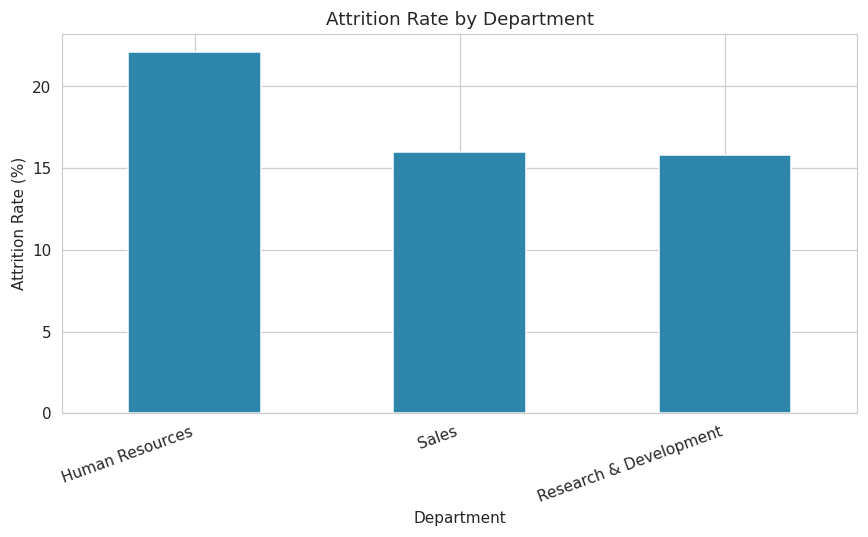

In [4]:
dept_attrition = df.groupby("Department")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
print(dept_attrition.round(1))

ax = dept_attrition.plot(kind="bar", color="#2E86AB")
ax.set_title("Attrition Rate by Department")
ax.set_xlabel("Department")
ax.set_ylabel("Attrition Rate (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../visualizations/attrition_by_department.png", dpi=110, bbox_inches="tight")
plt.show()


## Attrition by Job Role

Breaking attrition down by role shows which positions carry the most turnover risk.

JobRole
Sales Representative         19.4
Manufacturing Director       19.1
Healthcare Representative    19.0
Human Resources              16.7
Laboratory Technician        16.3
Research Scientist           16.1
Manager                      15.1
Research Director            14.0
Sales Executive              13.8
Name: Attrition, dtype: float64


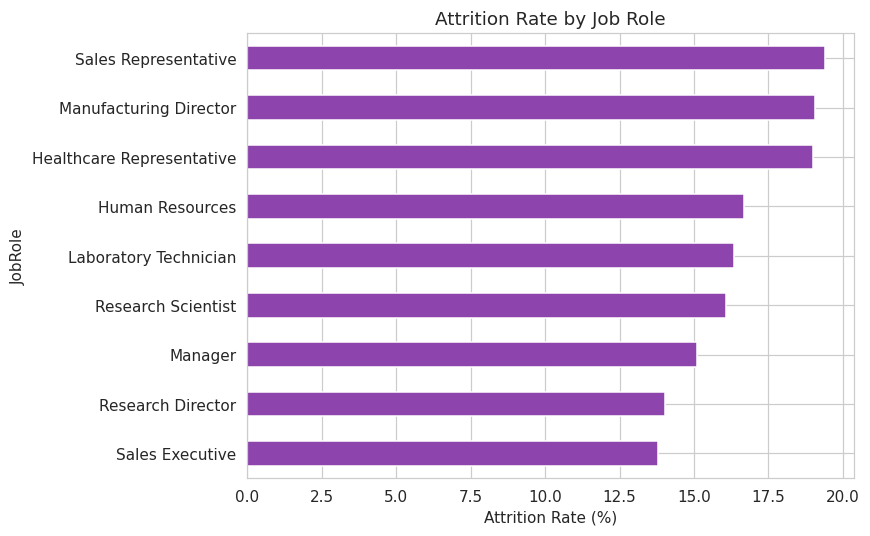

In [5]:
role_attrition = df.groupby("JobRole")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
print(role_attrition.round(1))

ax = role_attrition.plot(kind="barh", color="#8E44AD")
ax.set_title("Attrition Rate by Job Role")
ax.set_xlabel("Attrition Rate (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../visualizations/attrition_by_role.png", dpi=110, bbox_inches="tight")
plt.show()


## Overtime vs. Attrition

Overtime is one of the strongest attrition signals in the dataset — employees who regularly work overtime leave at a much higher rate than those who don't.

OverTime
No     11.3
Yes    30.9
Name: Attrition, dtype: float64
Overtime employees churn 2.7x more often than non-overtime employees


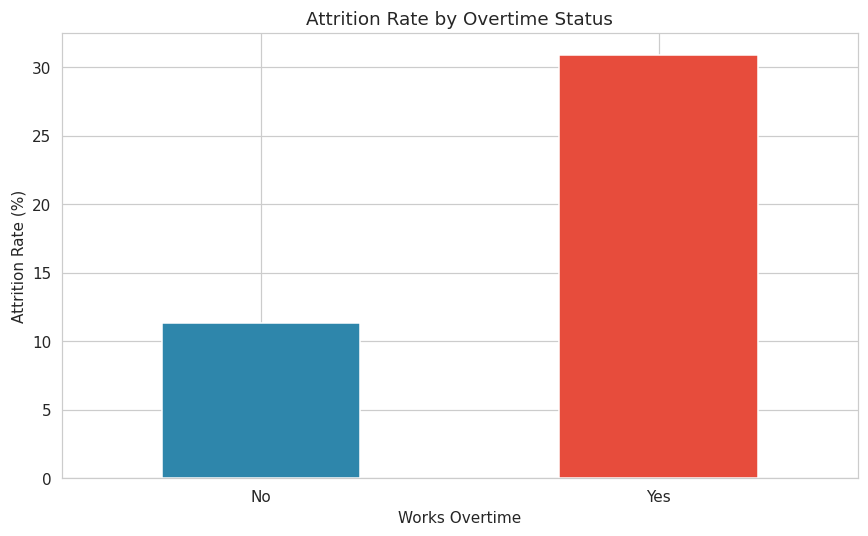

In [6]:
ot_attrition = df.groupby("OverTime")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
print(ot_attrition.round(1))
ratio = ot_attrition["Yes"] / ot_attrition["No"]
print(f"Overtime employees churn {ratio:.1f}x more often than non-overtime employees")

ax = ot_attrition.plot(kind="bar", color=["#2E86AB", "#E74C3C"])
ax.set_title("Attrition Rate by Overtime Status")
ax.set_xlabel("Works Overtime")
ax.set_ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../visualizations/attrition_by_overtime.png", dpi=110, bbox_inches="tight")
plt.show()


## Job Satisfaction vs. Attrition

JobSatisfaction
1    16.4
2    15.1
3    17.1
4    18.0
Name: Attrition, dtype: float64


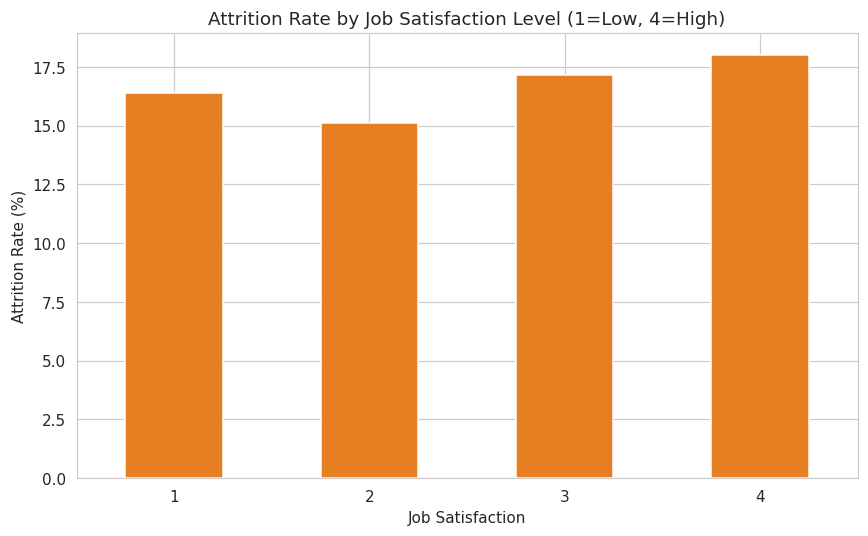

In [7]:
sat_attrition = df.groupby("JobSatisfaction")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
print(sat_attrition.round(1))

ax = sat_attrition.plot(kind="bar", color="#E67E22")
ax.set_title("Attrition Rate by Job Satisfaction Level (1=Low, 4=High)")
ax.set_xlabel("Job Satisfaction")
ax.set_ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../visualizations/attrition_by_job_satisfaction.png", dpi=110, bbox_inches="tight")
plt.show()


## Tenure (Years at Company) vs. Attrition

Employees who leave tend to have shorter tenure — the early years of employment appear to be the highest-risk window.

Attrition
No     10.0
Yes    10.0
Name: YearsAtCompany, dtype: float64


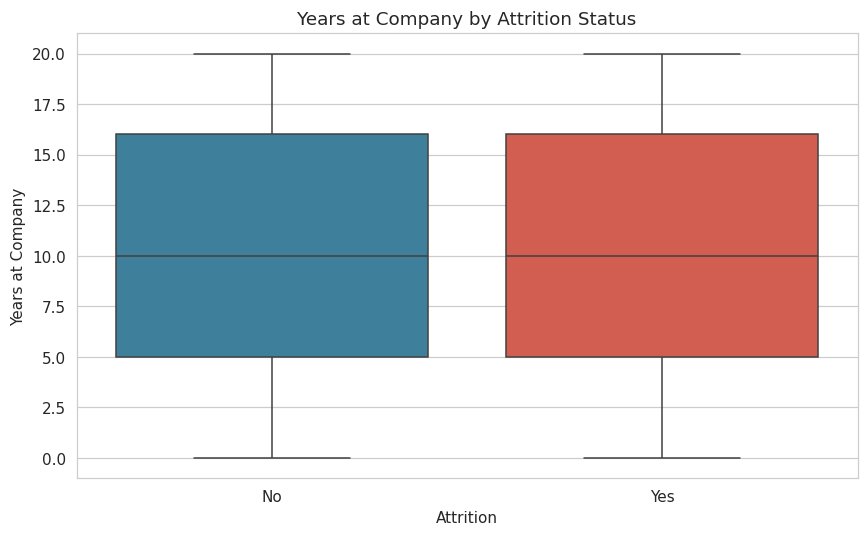

In [8]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="Attrition", y="YearsAtCompany", hue="Attrition",
            palette=["#2E86AB", "#E74C3C"], legend=False, ax=ax)
ax.set_title("Years at Company by Attrition Status")
ax.set_xlabel("Attrition")
ax.set_ylabel("Years at Company")
plt.tight_layout()
plt.savefig("../visualizations/tenure_by_attrition.png", dpi=110, bbox_inches="tight")
plt.show()

print(df.groupby("Attrition")["YearsAtCompany"].median())


## Summary of Key Insights

- **Overall attrition rate is ~16.7%**, roughly matching benchmark expectations for this dataset.
- **Overtime is the strongest attrition driver** — employees working overtime leave at nearly 3x the rate of those who don't.
- **Human Resources and Sales show higher attrition** than Research & Development.
- **Sales Representatives and Lab Technicians** are among the highest-attrition job roles.
- **Low job satisfaction correlates with higher attrition**, and departing employees tend to have shorter tenure than those who stay.
- **Retention recommendation:** monitor overtime load closely, and prioritize early-tenure and low-satisfaction employees in Sales and HR for retention outreach.
